# Fake News Detection on the LIAR Dataset
## Hand-crafted Features + MLP  vs.  BiLSTM on Raw Text

*Course project - binary fake-news classification with controlled model comparisons, statistical rigor, and error analysis.*

---

### Notebook structure
| # | Section |
|---|---------|
| 1 | Problem statement & challenges |
| 2 | Setup, reproducibility, data download |
| 3 | Data loading & exploratory data analysis (EDA) |
| 4 | Preprocessing & binary label definition |
| 5 | Baselines (majority class, logistic regression) |
| 6 | **Model A** - MLP on hand-crafted features |
| 7 | **Model B** - BiLSTM on raw statement text |
| 8 | **Experiment 1** - Controlled comparison: text-MLP vs. text-LSTM (multi-seed mean±std, McNemar) + training curves |
| 9 | **Experiment 2** - MLP feature ablation (text vs. metadata; credit-history leakage) |
| 10 | **Experiment 3** - LSTM design study (directionality, hidden size, pretrained GloVe) |
| 11 | **Experiment 4** - Class imbalance & decision-threshold tuning (PR curves) |
| - | **Part 2** - **Model C** DistilBERT (fine-tuned) · **Model D** Hybrid (BiLSTM + metadata fusion) |
| 12 | Final evaluation - model zoo: bootstrap 95% CIs, ROC/PR, confusion matrices, params/time, calibration |
| 13 | Error analysis (by label, length, confident errors, agreement) + word-importance interpretability |
| 15 | Interactive demo - predict on your own statement |
| 14 | Conclusions & insights |

## 1. Problem statement & challenges

**Goal.** Automatically classify short political statements as **fake** (untrustworthy) or **real** (trustworthy), using the [LIAR benchmark](https://aclanthology.org/P17-2067/) (Wang, ACL 2017): ~12.8K human-fact-checked statements from PolitiFact.

**Why it matters.** Manual fact-checking does not scale to the volume of online claims. A reliable classifier can triage statements for human reviewers.

**Modelling question (the core of this project).** Does an **LSTM that reads the raw text** beat a simpler **MLP on hand-crafted features** for this task? We run controlled experiments to find out *why* one wins.

**Why this is hard - challenges we will see in the data and analysis:**
- **Very short text.** LIAR statements average ~18 words. The dataset provides *statements*, not full article bodies, so there is little context for a sequence model to exploit. (This is the honest reality of LIAR; we flag it explicitly and analyse its consequences.)
- **Subtle, label-by-degree truth.** PolitiFact uses 6 graded labels (`pants-fire ... true`). Collapsing them to binary puts genuinely ambiguous cases (`barely-true`, `half-true`) right on the decision boundary.
- **Small data for deep learning.** ~10K training examples is small for training an LSTM from scratch.
- **Mild class imbalance** after binarization.
- **Metadata leakage trap.** LIAR ships per-speaker *credit-history* counts that are extremely predictive - but partly because they encode the answer. We treat this carefully as an experiment and an insight, not a free accuracy boost.

**Binary mapping (standard for LIAR).**
- `pants-fire`, `false`, `barely-true`  ->  **FAKE** (positive class = 1)
- `half-true`, `mostly-true`, `true`    ->  **REAL** (class = 0)

We report **precision and recall for the FAKE class** as the headline metrics: a fake-news detector is judged on how many flagged items are truly fake (precision) and how many fakes it catches (recall).

## 2. Setup & reproducibility

In [1]:
import importlib, subprocess, sys

def _ensure(pkg, pip_name=None):
    try:
        importlib.import_module(pkg)
    except Exception:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pip_name or pkg])

for _pkg, _pip in [("numpy", None), ("pandas", None), ("sklearn", "scikit-learn"),
                   ("scipy", None), ("matplotlib", None), ("seaborn", None),
                   ("nltk", None), ("torch", None)]:
    _ensure(_pkg, _pip)

print("Library check complete.")

Library check complete.


In [2]:
import os, re, random, time, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (precision_recall_fscore_support, f1_score, accuracy_score,
                             precision_score, recall_score, roc_auc_score, average_precision_score,
                             confusion_matrix, classification_report, precision_recall_curve, roc_curve)

import nltk
for _res in ["stopwords", "vader_lexicon", "punkt"]:
    try:
        nltk.download(_res, quiet=True)
    except Exception as e:
        print("NLTK download warning:", _res, e)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_colwidth", 120)

def set_seed(seed: int):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

GLOBAL_SEED = 42
set_seed(GLOBAL_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__, "| Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128 | Device: cuda
GPU: Tesla T4


In [3]:
CONFIG = {
    "MAX_TFIDF":      5000,    # vocab cap for hand-crafted TF-IDF features
    "MAX_VOCAB":      20000,   # vocab cap for the LSTM embedding layer
    "MIN_FREQ":       2,       # drop words seen < MIN_FREQ times when building LSTM vocab
    "MAX_LEN":        40,      # truncate statements to this many tokens for the LSTM
    "MLP_HIDDEN":     (256, 64),
    "MLP_EPOCHS":     40,
    "MLP_PATIENCE":   6,
    "EMBED_DIM":      128,
    "LSTM_HIDDEN":    128,
    "LSTM_EPOCHS":    30,
    "LSTM_PATIENCE":  5,
    "BATCH":          64,
    "LR":             1e-3,
    "DROPOUT":        0.5,
    "SEEDS_MAIN":     [0, 1, 2, 3, 4],   # seeds for the headline comparison
    "SEEDS_ABLATION": [0, 1, 2],         # fewer seeds for the cheaper studies
    "USE_GLOVE":      True,              # Exp 3 downloads GloVe via gensim (skips if unavailable)
    "REP_SEED":       123,               # seed for the final model-zoo / demo
    "USE_BERT":       True,              # fine-tune DistilBERT (skips if transformers/download unavailable)
    "BERT_MODEL":     "distilbert-base-uncased",
    "BERT_MAXLEN":    64,
    "BERT_EPOCHS":    3,
    "BERT_BATCH":     32,
    "BERT_LR":        2e-5,
    "BERT_PATIENCE":  2,
    "HYBRID_EPOCHS":  30,
    "N_BOOT":         1000,              # bootstrap resamples for the 95% CIs
}

print(json.dumps({k: str(v) for k, v in CONFIG.items()}, indent=2))

{
  "MAX_TFIDF": "5000",
  "MAX_VOCAB": "20000",
  "MIN_FREQ": "2",
  "MAX_LEN": "40",
  "MLP_HIDDEN": "(256, 64)",
  "MLP_EPOCHS": "40",
  "MLP_PATIENCE": "6",
  "EMBED_DIM": "128",
  "LSTM_HIDDEN": "128",
  "LSTM_EPOCHS": "30",
  "LSTM_PATIENCE": "5",
  "BATCH": "64",
  "LR": "0.001",
  "DROPOUT": "0.5",
  "SEEDS_MAIN": "[0, 1, 2, 3, 4]",
  "SEEDS_ABLATION": "[0, 1, 2]",
  "USE_GLOVE": "True",
  "REP_SEED": "123",
  "USE_BERT": "True",
  "BERT_MODEL": "distilbert-base-uncased",
  "BERT_MAXLEN": "64",
  "BERT_EPOCHS": "3",
  "BERT_BATCH": "32",
  "BERT_LR": "2e-05",
  "BERT_PATIENCE": "2",
  "HYBRID_EPOCHS": "30",
  "N_BOOT": "1000"
}


In [4]:
import urllib.request, zipfile

DATA_DIR = "data/liar"
TRAIN_TSV = os.path.join(DATA_DIR, "train.tsv")
if not os.path.exists(TRAIN_TSV):
    os.makedirs("data", exist_ok=True)
    url = "https://sites.cs.ucsb.edu/~william/data/liar_dataset.zip"
    print("Downloading LIAR dataset ...")
    urllib.request.urlretrieve(url, "data/liar_dataset.zip")
    with zipfile.ZipFile("data/liar_dataset.zip") as z:
        z.extractall(DATA_DIR)
    print("Done.")
print("Files:", sorted(os.listdir(DATA_DIR)))

Done.
Files: ['README', 'test.tsv', 'train.tsv', 'valid.tsv']


## 3. Data loading & exploratory data analysis

The LIAR TSV columns (per the dataset README): statement id, 6-way label, the statement text, subject(s), speaker, speaker job, state, party, five credit-history counts, and the context/venue.

In [5]:
COLS = ["id", "label", "statement", "subject", "speaker", "job", "state", "party",
        "barely_true_ct", "false_ct", "half_true_ct", "mostly_true_ct", "pants_fire_ct", "context"]

def load_split(name):
    df = pd.read_csv(os.path.join(DATA_DIR, f"{name}.tsv"), sep="\t", header=None, names=COLS, quoting=3)
    return df

train_df = load_split("train")
valid_df = load_split("valid")
test_df  = load_split("test")
print(f"train={len(train_df)}  valid={len(valid_df)}  test={len(test_df)}")
train_df.head(3)

train=10269  valid=1284  test=1283


,id,label,statement,subject,speaker,job,state,party,barely_true_ct,false_ct,half_true_ct,mostly_true_ct,pants_fire_ct,context
0,2635.json,false,Says the Annies List political group supports third-trimester abortions on demand.,abortion,dwayne-bohac,State representative,Texas,republican,0,1,0,0,0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started when natural gas took off that started to begin in (President George ...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0,0,1,1,0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by voting to give George Bush the benefit of the doubt on Iran.""",foreign-policy,barack-obama,President,Illinois,democrat,70,71,160,163,9,Denver


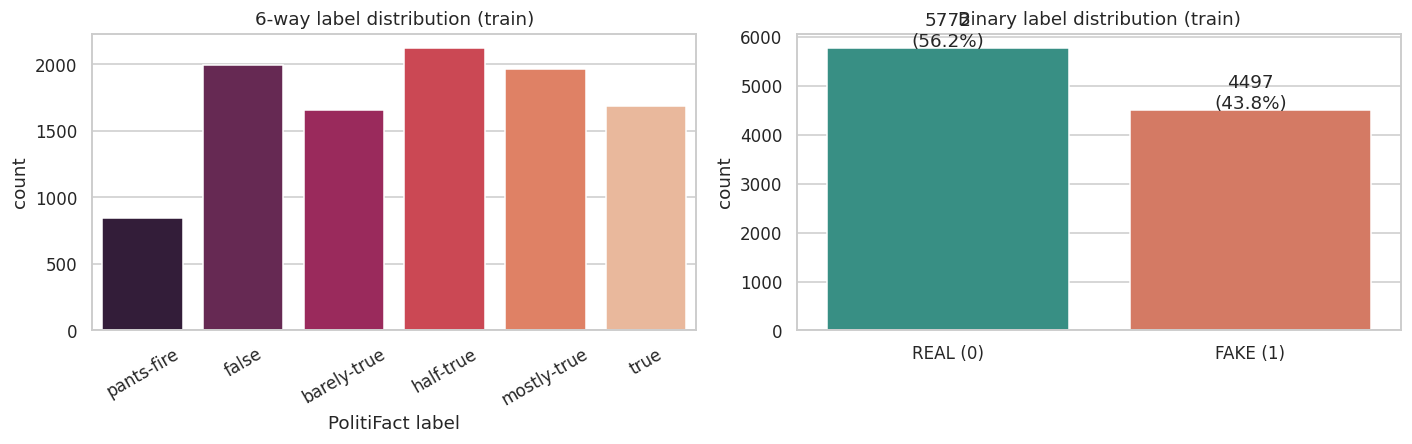

Binary balance (train): FAKE = 43.8%, REAL = 56.2%


In [6]:
LABEL6 = ["pants-fire", "false", "barely-true", "half-true", "mostly-true", "true"]
counts6 = train_df["label"].value_counts().reindex(LABEL6)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
sns.barplot(x=list(counts6.index), y=counts6.values, hue=list(counts6.index),
            legend=False, palette="rocket", ax=ax[0])
ax[0].set_title("6-way label distribution (train)")
ax[0].set_xlabel("PolitiFact label"); ax[0].set_ylabel("count")
ax[0].tick_params(axis="x", rotation=30)

FAKE_LABELS = {"pants-fire", "false", "barely-true"}
def to_binary(label):
    return 1 if label in FAKE_LABELS else 0   # 1 = FAKE (positive), 0 = REAL

for df in (train_df, valid_df, test_df):
    df["y"] = df["label"].map(to_binary)

binc = train_df["y"].value_counts().reindex([0, 1])
sns.barplot(x=["REAL (0)", "FAKE (1)"], y=binc.values, hue=["REAL (0)", "FAKE (1)"],
            legend=False, palette=["#2a9d8f", "#e76f51"], ax=ax[1])
ax[1].set_title("Binary label distribution (train)")
ax[1].set_ylabel("count")
for i, v in enumerate(binc.values):
    ax[1].text(i, v + 30, f"{v}\n({v/len(train_df)*100:.1f}%)", ha="center")
plt.tight_layout(); plt.show()

print("Binary balance (train): FAKE = {:.1%}, REAL = {:.1%}".format(
      train_df["y"].mean(), 1 - train_df["y"].mean()))

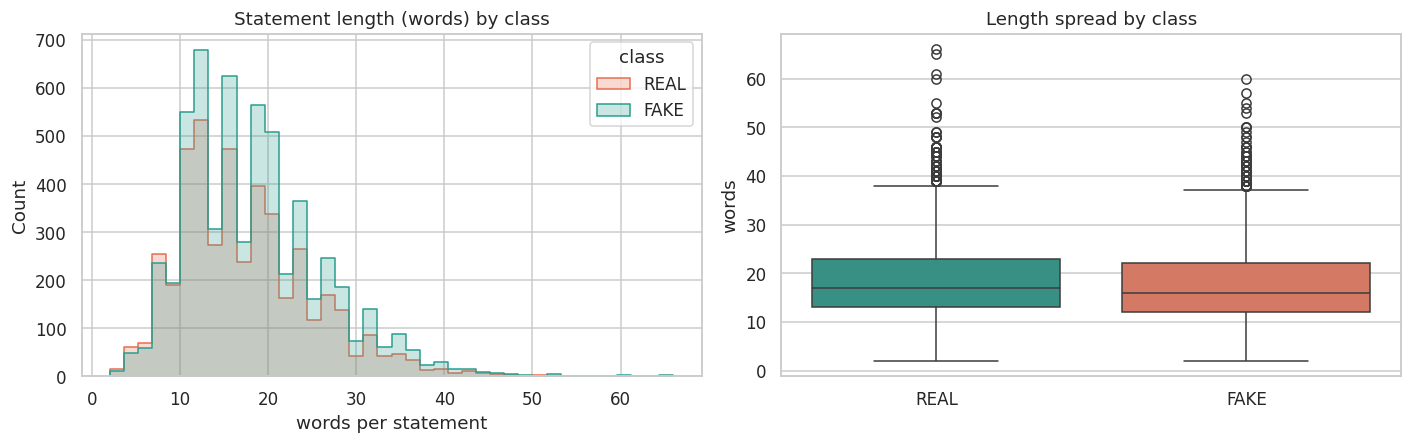

mean    17.906515
50%     17.000000
max     66.000000

Key EDA takeaway: statements are SHORT (median ~17 words). There is little raw text for a sequence model to learn from.


In [7]:
train_df["n_words"] = train_df["statement"].str.split().apply(len)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
sns.histplot(data=train_df, x="n_words", hue="y", bins=40, ax=ax[0],
             palette=["#2a9d8f", "#e76f51"], element="step")
ax[0].set_title("Statement length (words) by class")
ax[0].set_xlabel("words per statement")
ax[0].legend(title="class", labels=["REAL", "FAKE"])

sns.boxplot(data=train_df, x="y", y="n_words", hue="y", legend=False, ax=ax[1],
            palette=["#2a9d8f", "#e76f51"])
ax[1].set_xticklabels(["REAL", "FAKE"]); ax[1].set_xlabel("")
ax[1].set_title("Length spread by class"); ax[1].set_ylabel("words")
plt.tight_layout(); plt.show()

print(train_df["n_words"].describe()[["mean", "50%", "max"]].to_string())
print("\nKey EDA takeaway: statements are SHORT (median ~{:.0f} words). "
      "There is little raw text for a sequence model to learn from."
      .format(train_df["n_words"].median()))

=== FAKE examples ===
 - Says the Annies List political group supports third-trimester abortions on demand.
 - Health care reform legislation is likely to mandate free sex change surgeries.
 - Jim Dunnam has not lived in the district he represents for years now.

=== REAL examples ===
 - When did the decline of coal start? It started when natural gas took off that started to begin in (President George W.) Bushs administration.
 - Hillary Clinton agrees with John McCain "by voting to give George Bush the benefit of the doubt on Iran."
 - The economic turnaround started at the end of my term.


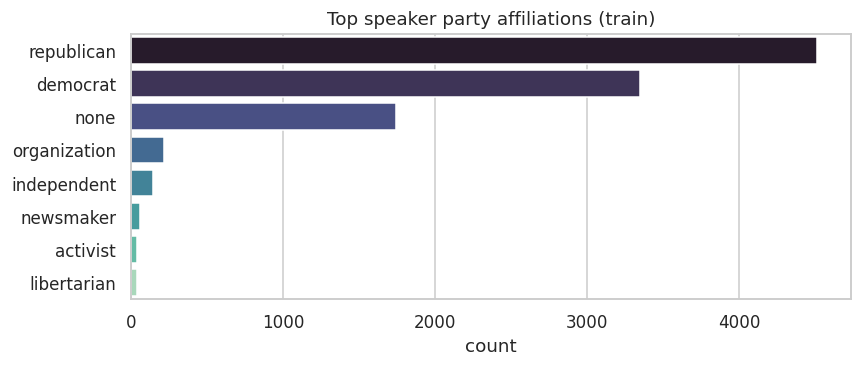

In [8]:
print("=== FAKE examples ===")
for s in train_df[train_df.y == 1]["statement"].head(3):
    print(" -", s)
print("\n=== REAL examples ===")
for s in train_df[train_df.y == 0]["statement"].head(3):
    print(" -", s)

plt.figure(figsize=(8, 3.5))
top_party = train_df["party"].fillna("none").value_counts().head(8)
sns.barplot(x=top_party.values, y=list(top_party.index), hue=list(top_party.index),
            legend=False, palette="mako")
plt.title("Top speaker party affiliations (train)"); plt.xlabel("count"); plt.tight_layout(); plt.show()

## 4. Preprocessing & feature construction

We keep the dataset's **official train/validation/test splits** (no leakage from re-splitting). All vectorizers, scalers, and vocabularies are **fit on train only**, then applied to validation and test.

We build two completely separate input representations so the comparison is clean:
- **For the MLP** - hand-crafted features: (a) **TF-IDF** of the statement, (b) **linguistic** features (length, punctuation, sentiment, lexical diversity), (c) **metadata** (party, speaker credit-history counts).
- **For the LSTM** - the **raw tokenised statement** only.

In [9]:
STOPWORDS = set(nltk.corpus.stopwords.words("english"))
from nltk.sentiment import SentimentIntensityAnalyzer
try:
    _sia = SentimentIntensityAnalyzer()
except Exception:
    nltk.download("vader_lexicon", quiet=True); _sia = SentimentIntensityAnalyzer()

def clean_text(t):
    t = "" if pd.isna(t) else str(t)
    return t.strip()

def linguistic_features(text):
    t = clean_text(text)
    words = t.split()
    n_words = max(len(words), 1)
    lower = t.lower()
    toks = re.findall(r"[a-z']+", lower)
    n_chars   = len(t)
    n_unique  = len(set(w.lower() for w in words))
    ttr       = n_unique / n_words                          # type-token ratio (lexical diversity)
    avg_wlen  = np.mean([len(w) for w in words]) if words else 0.0
    n_exclaim = t.count("!")
    n_quest   = t.count("?")
    n_digits  = sum(c.isdigit() for c in t)
    n_caps    = sum(1 for w in words if len(w) > 1 and w.isupper())
    n_stop    = sum(1 for w in toks if w in STOPWORDS)
    stop_frac = n_stop / n_words
    sentiment = _sia.polarity_scores(t)["compound"]
    return [n_words, n_chars, n_unique, ttr, avg_wlen, n_exclaim,
            n_quest, n_digits, n_caps, stop_frac, sentiment]

LING_NAMES = ["n_words", "n_chars", "n_unique", "ttr", "avg_word_len", "n_exclaim",
              "n_question", "n_digits", "n_caps_words", "stopword_frac", "sentiment"]

def build_ling_matrix(df):
    return np.array([linguistic_features(t) for t in df["statement"]], dtype=np.float32)

X_ling_train = build_ling_matrix(train_df)
X_ling_valid = build_ling_matrix(valid_df)
X_ling_test  = build_ling_matrix(test_df)
print("Linguistic feature matrix:", X_ling_train.shape, "->", LING_NAMES)

Linguistic feature matrix: (10269, 11) -> ['n_words', 'n_chars', 'n_unique', 'ttr', 'avg_word_len', 'n_exclaim', 'n_question', 'n_digits', 'n_caps_words', 'stopword_frac', 'sentiment']


In [10]:
tfidf = TfidfVectorizer(max_features=CONFIG["MAX_TFIDF"], ngram_range=(1, 2),
                        sublinear_tf=True, min_df=2, stop_words="english")
Xtf_train = tfidf.fit_transform(train_df["statement"])
Xtf_valid = tfidf.transform(valid_df["statement"])
Xtf_test  = tfidf.transform(test_df["statement"])
print("TF-IDF matrix (sparse):", Xtf_train.shape)

CREDIT_COLS = ["barely_true_ct", "false_ct", "half_true_ct", "mostly_true_ct", "pants_fire_ct"]
TOP_PARTIES = train_df["party"].fillna("none").value_counts().head(6).index.tolist()

def build_meta_matrix(df):
    credit = df[CREDIT_COLS].apply(pd.to_numeric, errors="coerce").fillna(0).values.astype(np.float32)
    party  = df["party"].fillna("none")
    onehot = np.zeros((len(df), len(TOP_PARTIES) + 1), dtype=np.float32)
    for i, p in enumerate(party):
        if p in TOP_PARTIES:
            onehot[i, TOP_PARTIES.index(p)] = 1.0
        else:
            onehot[i, -1] = 1.0   # "other"
    return np.hstack([credit, onehot])

X_meta_train = build_meta_matrix(train_df)
X_meta_valid = build_meta_matrix(valid_df)
X_meta_test  = build_meta_matrix(test_df)
print("Metadata matrix:", X_meta_train.shape)

ling_scaler = StandardScaler().fit(X_ling_train)
meta_scaler = StandardScaler().fit(X_meta_train)
X_ling_train_s, X_ling_valid_s, X_ling_test_s = (ling_scaler.transform(m) for m in (X_ling_train, X_ling_valid, X_ling_test))
X_meta_train_s, X_meta_valid_s, X_meta_test_s = (meta_scaler.transform(m) for m in (X_meta_train, X_meta_valid, X_meta_test))

y_train = train_df["y"].values.astype(np.float32)
y_valid = valid_df["y"].values.astype(np.float32)
y_test  = test_df["y"].values.astype(np.float32)

TF-IDF matrix (sparse): (10269, 5000)
Metadata matrix: (10269, 12)


In [11]:
def make_features(groups):
    def stack(split):
        parts = []
        if "tfidf" in groups: parts.append({"train": Xtf_train, "valid": Xtf_valid, "test": Xtf_test}[split].toarray().astype(np.float32))
        if "ling"  in groups: parts.append({"train": X_ling_train_s, "valid": X_ling_valid_s, "test": X_ling_test_s}[split])
        if "meta"  in groups: parts.append({"train": X_meta_train_s, "valid": X_meta_valid_s, "test": X_meta_test_s}[split])
        return np.hstack(parts).astype(np.float32)
    return stack("train"), stack("valid"), stack("test")

Xtr_all,  Xva_all,  Xte_all  = make_features(["tfidf", "ling", "meta"])  # text + metadata
Xtr_text, Xva_text, Xte_text = make_features(["tfidf", "ling"])          # hand-crafted TEXT features only
print("Text+meta MLP feature dim:", Xtr_all.shape[1])
print("Text-only MLP feature dim:", Xtr_text.shape[1], "(used for the controlled MLP-vs-LSTM comparison)")

Text+meta MLP feature dim: 5023
Text-only MLP feature dim: 5011 (used for the controlled MLP-vs-LSTM comparison)


## 5. Shared training & evaluation utilities

Both the MLP and the LSTM are implemented in PyTorch and trained by the **same** loop (Adam, `BCEWithLogitsLoss`, early stopping on validation F1). This keeps the comparison controlled - any performance gap comes from the *model/representation*, not from different training regimes.

In [12]:
@torch.no_grad()
def predict_probs(model, loader):
    model.eval()
    ys, ps = [], []
    for inputs, y in loader:
        if isinstance(inputs, (list, tuple)):
            inputs = [t.to(device) for t in inputs]
            logit = model(*inputs)
        else:
            logit = model(inputs.to(device))
        ps.append(torch.sigmoid(logit).detach().cpu().numpy())
        ys.append(y.numpy())
    return np.concatenate(ys), np.concatenate(ps)

def train_model(model, train_loader, valid_loader, epochs, lr, patience, pos_weight=None, verbose=False):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    pw = None if pos_weight is None else torch.tensor([pos_weight], device=device)
    crit = nn.BCEWithLogitsLoss(pos_weight=pw)
    best_f1, best_state, bad = -1.0, None, 0
    history = []
    for ep in range(epochs):
        model.train(); running = 0.0
        for inputs, y in train_loader:
            y = y.to(device).float()
            if isinstance(inputs, (list, tuple)):
                inputs = [t.to(device) for t in inputs]; logit = model(*inputs)
            else:
                logit = model(inputs.to(device))
            loss = crit(logit, y)
            opt.zero_grad(); loss.backward(); opt.step()
            running += loss.item() * len(y)
        yv, pv = predict_probs(model, valid_loader)
        vf1 = f1_score(yv, (pv >= 0.5).astype(int), zero_division=0)
        history.append({"epoch": ep, "train_loss": running / len(train_loader.dataset), "val_f1": vf1})
        if vf1 > best_f1:
            best_f1, bad = vf1, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
        if verbose:
            print(f"  epoch {ep:02d}  loss={history[-1]['train_loss']:.4f}  val_f1={vf1:.4f}")
        if bad >= patience:
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", pos_label=1, zero_division=0)
    return {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": p, "recall": r, "f1": f1,
        "roc_auc":   roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float("nan"),
        "pr_auc":    average_precision_score(y_true, y_prob),
    }

In [13]:
class MLPClassifier(nn.Module):
    def __init__(self, in_dim, hidden=(256, 64), dropout=0.5):
        super().__init__()
        layers, d = [], in_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.BatchNorm1d(h), nn.Dropout(dropout)]
            d = h
        layers += [nn.Linear(d, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).squeeze(1)

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden=128, bidirectional=True,
                 dropout=0.5, pad_idx=0, pretrained=None, freeze=False):
        super().__init__()
        self.bidir = bidirectional
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        if pretrained is not None:
            self.embedding.weight.data.copy_(torch.tensor(pretrained, dtype=torch.float))
            self.embedding.weight.requires_grad = not freeze
        self.lstm = nn.LSTM(embed_dim, hidden, batch_first=True, bidirectional=bidirectional)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden * (2 if bidirectional else 1), 1)
    def forward(self, x, lengths):
        emb = self.drop(self.embedding(x))
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h, _) = self.lstm(packed)
        feat = torch.cat([h[-2], h[-1]], dim=1) if self.bidir else h[-1]
        return self.fc(self.drop(feat)).squeeze(1)

## 6 & 7. Data loaders for each model

The MLP consumes dense feature tensors; the LSTM consumes padded token-id sequences (packed with their true lengths so padding never affects the recurrence).

In [14]:
def mlp_loaders(Xtr, Xva, Xte, batch=64, seed=0):
    g = torch.Generator(); g.manual_seed(seed)
    def ds(X, y): return TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    tr = DataLoader(ds(Xtr, y_train), batch_size=batch, shuffle=True, generator=g)
    va = DataLoader(ds(Xva, y_valid), batch_size=256)
    te = DataLoader(ds(Xte, y_test),  batch_size=256)
    return tr, va, te

from collections import Counter
def tokenize(text):
    return re.findall(r"[a-z0-9']+", str(text).lower())

def build_vocab(texts, min_freq=2, max_size=20000):
    c = Counter()
    for t in texts: c.update(tokenize(t))
    itos = ["<pad>", "<unk>"] + [w for w, f in c.most_common() if f >= min_freq][:max_size]
    return {w: i for i, w in enumerate(itos)}, itos

stoi, itos = build_vocab(train_df["statement"], CONFIG["MIN_FREQ"], CONFIG["MAX_VOCAB"])
VOCAB_SIZE = len(itos)
print("LSTM vocab size:", VOCAB_SIZE)

def encode(text, max_len):
    ids = [stoi.get(w, 1) for w in tokenize(text)][:max_len]
    return ids if ids else [1]

train_seqs = [encode(t, CONFIG["MAX_LEN"]) for t in train_df["statement"]]
valid_seqs = [encode(t, CONFIG["MAX_LEN"]) for t in valid_df["statement"]]
test_seqs  = [encode(t, CONFIG["MAX_LEN"]) for t in test_df["statement"]]

class TextDataset(Dataset):
    def __init__(self, seqs, labels): self.seqs, self.labels = seqs, labels
    def __len__(self): return len(self.seqs)
    def __getitem__(self, i): return self.seqs[i], self.labels[i]

def collate(batch):
    seqs, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in seqs], dtype=torch.long)
    maxlen = int(lengths.max())
    padded = torch.zeros(len(seqs), maxlen, dtype=torch.long)
    for i, s in enumerate(seqs):
        padded[i, :len(s)] = torch.tensor(s, dtype=torch.long)
    return (padded, lengths), torch.tensor(labels, dtype=torch.float)

def lstm_loaders(batch=64, seed=0):
    g = torch.Generator(); g.manual_seed(seed)
    tr = DataLoader(TextDataset(train_seqs, y_train), batch_size=batch, shuffle=True, collate_fn=collate, generator=g)
    va = DataLoader(TextDataset(valid_seqs, y_valid), batch_size=256, collate_fn=collate)
    te = DataLoader(TextDataset(test_seqs,  y_test),  batch_size=256, collate_fn=collate)
    return tr, va, te

LSTM vocab size: 6946


## 5b. Baselines

Before the neural models, we establish reference points so later numbers are interpretable:
- **Majority-class** classifier (predicts REAL for everything).
- **Logistic regression** on TF-IDF, and on TF-IDF + metadata.

In [15]:
baseline_rows = []

maj = DummyClassifier(strategy="most_frequent").fit(Xtf_train, y_train)
m = compute_metrics(y_test, maj.predict_proba(Xtf_test)[:, 1]); m["model"] = "Majority class"; baseline_rows.append(m)

lr_tf = LogisticRegression(max_iter=2000, C=1.0).fit(Xtf_train, y_train)
m = compute_metrics(y_test, lr_tf.predict_proba(Xtf_test)[:, 1]); m["model"] = "LogReg (TF-IDF)"; baseline_rows.append(m)

Xtr_tm = sp.hstack([Xtf_train, sp.csr_matrix(X_meta_train_s)]).tocsr()
Xte_tm = sp.hstack([Xtf_test,  sp.csr_matrix(X_meta_test_s)]).tocsr()
lr_tm = LogisticRegression(max_iter=2000, C=1.0).fit(Xtr_tm, y_train)
m = compute_metrics(y_test, lr_tm.predict_proba(Xte_tm)[:, 1]); m["model"] = "LogReg (TF-IDF + meta)"; baseline_rows.append(m)

baseline_df = pd.DataFrame(baseline_rows).set_index("model")[["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]]
baseline_df.round(4)

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Majority class,0.5666,0.0000,0.0000,0.0000,0.5000,0.4334
LogReg (TF-IDF),0.6118,0.5690,0.4299,0.4898,0.6496,0.5984
LogReg (TF-IDF + meta),0.6422,0.6125,0.4748,0.5350,0.6772,0.6182


## 8. Experiment 1 - Controlled comparison: MLP vs. BiLSTM (text only)

This is the comparison the brief asks for, set up **fairly**: both models see the **statement text and nothing else**.
- **MLP** on **hand-crafted *text* features** (TF-IDF + linguistic features). *No metadata* - that would be an unfair advantage the LSTM doesn't get.
- **BiLSTM** on the **raw tokenised text**.

We train each over **multiple random seeds** and report **mean +/- std** (single-run numbers on a 1.3K test set are noisy), then run **McNemar's test** on the paired test predictions to check whether the difference is *statistically significant*. (What *metadata* adds on top is the subject of Experiment 2.)

In [16]:
def run_mlp(Xtr, Xva, Xte, seed, hidden=None, dropout=None, epochs=None, return_probs=False):
    set_seed(seed)
    tr, va, te = mlp_loaders(Xtr, Xva, Xte, CONFIG["BATCH"], seed)
    model = MLPClassifier(Xtr.shape[1], hidden or CONFIG["MLP_HIDDEN"], dropout or CONFIG["DROPOUT"])
    model, hist = train_model(model, tr, va, epochs or CONFIG["MLP_EPOCHS"], CONFIG["LR"], CONFIG["MLP_PATIENCE"])
    yt, pt = predict_probs(model, te)
    met = compute_metrics(yt, pt)
    return (met, pt, hist) if return_probs else met

def run_lstm(seed, bidirectional=True, hidden=None, pretrained=None, freeze=False,
             pos_weight=None, epochs=None, return_probs=False):
    set_seed(seed)
    tr, va, te = lstm_loaders(CONFIG["BATCH"], seed)
    model = LSTMClassifier(VOCAB_SIZE, CONFIG["EMBED_DIM"], hidden or CONFIG["LSTM_HIDDEN"],
                           bidirectional=bidirectional, dropout=CONFIG["DROPOUT"],
                           pretrained=pretrained, freeze=freeze)
    model, hist = train_model(model, tr, va, epochs or CONFIG["LSTM_EPOCHS"], CONFIG["LR"],
                              CONFIG["LSTM_PATIENCE"], pos_weight=pos_weight)
    yt, pt = predict_probs(model, te)
    met = compute_metrics(yt, pt)
    return (met, pt, hist) if return_probs else met

def summarize(runs):
    df = pd.DataFrame(runs)
    return df.mean(numeric_only=True), df.std(numeric_only=True)

In [17]:
t0 = time.time()
mlp_runs, lstm_runs = [], []
for s in CONFIG["SEEDS_MAIN"]:
    mlp_runs.append(run_mlp(Xtr_text, Xva_text, Xte_text, s))   # TEXT features only (fair comparison)
    lstm_runs.append(run_lstm(s, bidirectional=True))
    print(f"seed {s} done  |  MLP(text) F1={mlp_runs[-1]['f1']:.3f}  BiLSTM(text) F1={lstm_runs[-1]['f1']:.3f}")
print(f"\nExperiment 1 finished in {time.time()-t0:.0f}s over {len(CONFIG['SEEDS_MAIN'])} seeds.")

mlp_mean, mlp_std = summarize(mlp_runs)
lstm_mean, lstm_std = summarize(lstm_runs)
comp = pd.DataFrame({
    "MLP (text feats) mean":  mlp_mean, "MLP std":  mlp_std,
    "BiLSTM (text) mean":     lstm_mean, "BiLSTM std": lstm_std,
}).loc[["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]]
comp.round(4)

seed 0 done  |  MLP(text) F1=0.529  BiLSTM(text) F1=0.527
seed 1 done  |  MLP(text) F1=0.519  BiLSTM(text) F1=0.513
seed 2 done  |  MLP(text) F1=0.511  BiLSTM(text) F1=0.520
seed 3 done  |  MLP(text) F1=0.502  BiLSTM(text) F1=0.528
seed 4 done  |  MLP(text) F1=0.512  BiLSTM(text) F1=0.559

Experiment 1 finished in 138s over 5 seeds.


,MLP (text feats) mean,MLP std,BiLSTM (text) mean,BiLSTM std
accuracy,0.5920,0.0129,0.6028,0.0123
precision,0.5316,0.0170,0.5441,0.0152
recall,0.4986,0.0096,0.5162,0.0259
f1,0.5144,0.0101,0.5295,0.0177
roc_auc,0.6193,0.0129,0.6375,0.0115
pr_auc,0.5488,0.0151,0.5612,0.0156


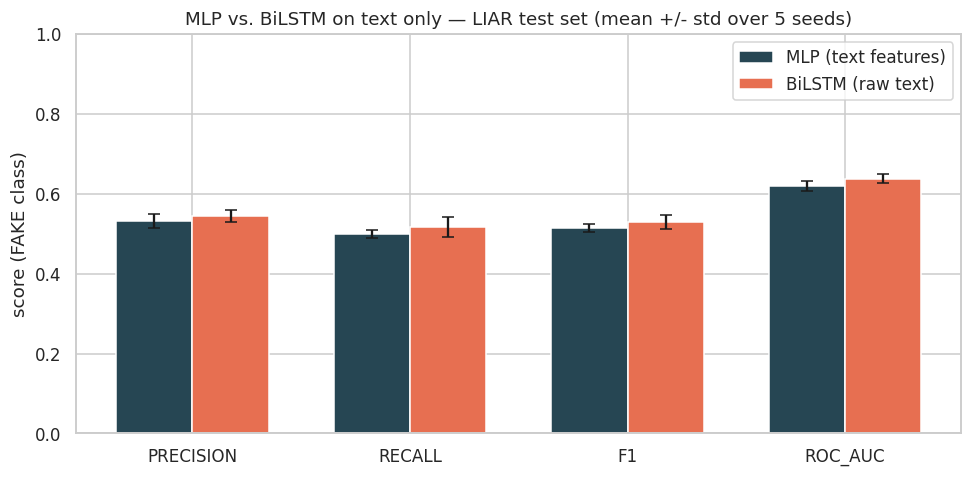

In [ ]:
metrics_to_plot = ["precision", "recall", "f1", "roc_auc"]
x = np.arange(len(metrics_to_plot)); w = 0.35
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x - w/2, [mlp_mean[m] for m in metrics_to_plot],  w, yerr=[mlp_std[m] for m in metrics_to_plot],
       capsize=4, label="MLP (text features)", color="#264653")
ax.bar(x + w/2, [lstm_mean[m] for m in metrics_to_plot], w, yerr=[lstm_std[m] for m in metrics_to_plot],
       capsize=4, label="BiLSTM (raw text)", color="#e76f51")
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylabel("score (FAKE class)"); ax.set_ylim(0, 1)
ax.set_title(f"MLP vs. BiLSTM on text only - LIAR test set (mean +/- std over {len(CONFIG['SEEDS_MAIN'])} seeds)")
ax.legend(); plt.tight_layout(); plt.show()

In [19]:
from scipy.stats import chi2
set_seed(7)
_, mlp_p, _  = run_mlp(Xtr_text, Xva_text, Xte_text, 7, return_probs=True)
_, lstm_p, _ = run_lstm(7, bidirectional=True, return_probs=True)
mlp_pred  = (mlp_p  >= 0.5).astype(int)
lstm_pred = (lstm_p >= 0.5).astype(int)

mlp_correct  = (mlp_pred  == y_test.astype(int))
lstm_correct = (lstm_pred == y_test.astype(int))
b = int(np.sum(mlp_correct & ~lstm_correct))   # MLP right, LSTM wrong
c = int(np.sum(~mlp_correct & lstm_correct))    # LSTM right, MLP wrong
stat = (abs(b - c) - 1) ** 2 / (b + c) if (b + c) > 0 else 0.0
pval = chi2.sf(stat, 1)
print(f"McNemar contingency:  MLP-only-correct b={b}   LSTM-only-correct c={c}")
print(f"McNemar chi2 = {stat:.3f},  p-value = {pval:.4f}")
print("=> " + ("Significant difference (p < 0.05)." if pval < 0.05 else
                "No statistically significant difference (p >= 0.05)."))

McNemar contingency:  MLP-only-correct b=203   LSTM-only-correct c=212
McNemar chi2 = 0.154,  p-value = 0.6945
=> No statistically significant difference (p >= 0.05).


**Reading Experiment 1.** On **text alone**, the MLP and BiLSTM are close - and both sit only modestly above the logistic-regression baseline. This is the honest result: *surface text barely separates fake from real on LIAR*. The "fancier" sequence model does **not** clearly beat a bag-of-features MLP, because ~18-word statements give the recurrence little to exploit. McNemar's test tells us whether the small gap is real or noise. The interesting question - *what actually moves the needle* - is answered next: **metadata** (Exp 2).

### 8b. Training dynamics

Loss and validation-F1 curves for one representative run of each model. These show convergence behaviour, that **early stopping** fires (we restore the best-validation-F1 epoch), and the relative **overfitting** tendency of each model.

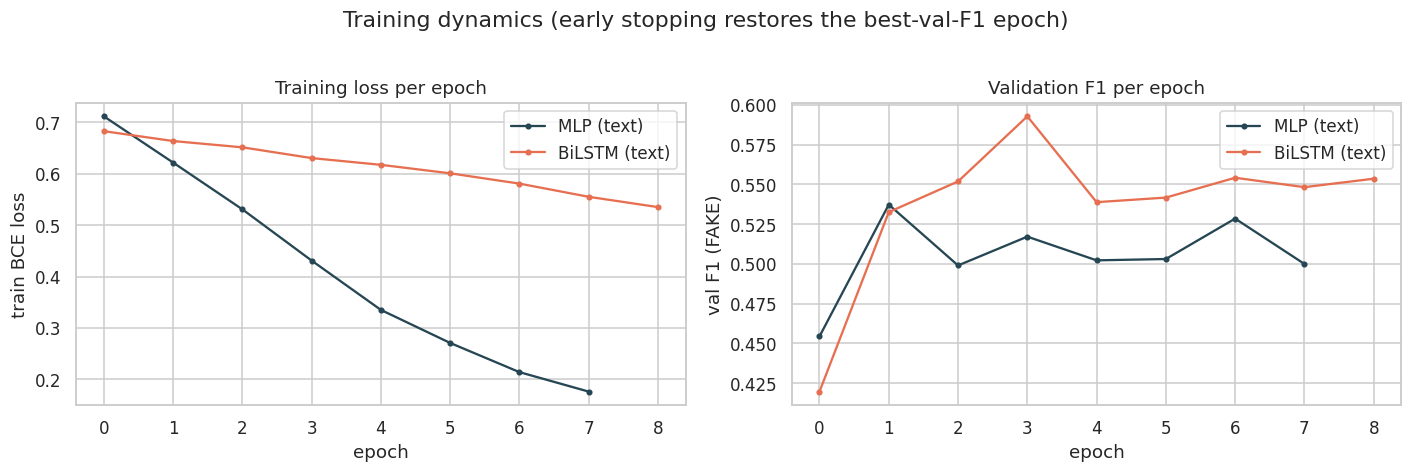

In [20]:
set_seed(CONFIG["REP_SEED"])
_, _, mlp_hist  = run_mlp(Xtr_text, Xva_text, Xte_text, CONFIG["REP_SEED"], return_probs=True)
set_seed(CONFIG["REP_SEED"])
_, _, lstm_hist = run_lstm(CONFIG["REP_SEED"], bidirectional=True, return_probs=True)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
for h, name, col in [(mlp_hist, "MLP (text)", "#264653"), (lstm_hist, "BiLSTM (text)", "#e76f51")]:
    ep = [r["epoch"] for r in h]
    ax[0].plot(ep, [r["train_loss"] for r in h], marker="o", ms=3, label=name, color=col)
    ax[1].plot(ep, [r["val_f1"]     for r in h], marker="o", ms=3, label=name, color=col)
ax[0].set_title("Training loss per epoch"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("train BCE loss"); ax[0].legend()
ax[1].set_title("Validation F1 per epoch"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("val F1 (FAKE)"); ax[1].legend()
plt.suptitle("Training dynamics (early stopping restores the best-val-F1 epoch)", y=1.02)
plt.tight_layout(); plt.show()

## 9. Experiment 2 - MLP feature ablation: where does the signal come from?

We hold the model fixed (same MLP) and vary **only the input features**, isolating each group's contribution:

| Config | Features |
|--------|----------|
| `text` | TF-IDF only |
| `text+ling` | + linguistic features |
| `text+meta` | + speaker metadata (party, credit history) |
| `all` | everything |
| `meta-only` | metadata only (no text at all) |

**Caveat we test head-on:** LIAR's credit-history counts include the current statement, so they leak speaker-level truthfulness priors. The `meta-only` row exposes how much of our accuracy is really "who is speaking?" rather than "what was said?".

In [21]:
ablation_specs = {
    "text":       ["tfidf"],
    "text+ling":  ["tfidf", "ling"],
    "text+meta":  ["tfidf", "meta"],
    "all":        ["tfidf", "ling", "meta"],
    "meta-only":  ["meta"],
}
ablation_rows = []
for name, groups in ablation_specs.items():
    Xtr, Xva, Xte = make_features(groups)
    runs = [run_mlp(Xtr, Xva, Xte, s) for s in CONFIG["SEEDS_ABLATION"]]
    mean, std = summarize(runs)
    ablation_rows.append({"config": name, "dim": Xtr.shape[1],
                          "precision": mean["precision"], "recall": mean["recall"],
                          "f1": mean["f1"], "f1_std": std["f1"], "roc_auc": mean["roc_auc"]})
    print(f"{name:11s} dim={Xtr.shape[1]:5d}  F1={mean['f1']:.3f} +/- {std['f1']:.3f}")

ablation_df = pd.DataFrame(ablation_rows).set_index("config")
ablation_df.round(4)

text        dim= 5000  F1=0.509 +/- 0.019
text+ling   dim= 5011  F1=0.520 +/- 0.009
text+meta   dim= 5012  F1=0.563 +/- 0.012
all         dim= 5023  F1=0.567 +/- 0.012
meta-only   dim=   12  F1=0.641 +/- 0.007


,dim,precision,recall,f1,f1_std,roc_auc
config,,,,,,
text,5000,0.5581,0.4688,0.5094,0.0189,0.6462
text+ling,5011,0.5356,0.5048,0.5196,0.0090,0.6226
text+meta,5012,0.5791,0.5480,0.5631,0.0117,0.6688
all,5023,0.5783,0.5564,0.5668,0.0122,0.6676
meta-only,12,0.6810,0.6067,0.6414,0.0074,0.7533


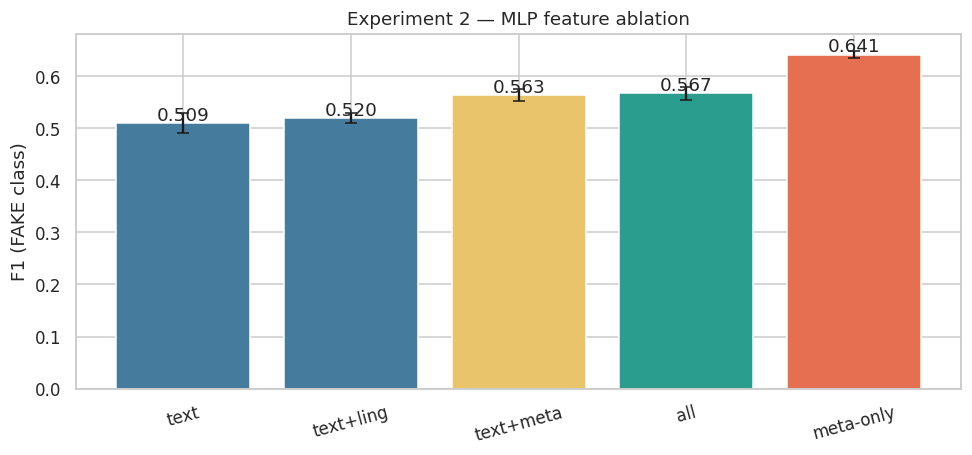

Insight: compare 'text' vs 'text+meta' vs 'meta-only' to see how much signal is
speaker credibility (metadata) rather than the words themselves.


In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.3))
order = ["text", "text+ling", "text+meta", "all", "meta-only"]
vals = ablation_df.loc[order, "f1"]; errs = ablation_df.loc[order, "f1_std"]
colors = ["#457b9d", "#457b9d", "#e9c46a", "#2a9d8f", "#e76f51"]
ax.bar(order, vals, yerr=errs, capsize=4, color=colors)
ax.set_ylabel("F1 (FAKE class)"); ax.set_title("Experiment 2 - MLP feature ablation")
for i, v in enumerate(vals): ax.text(i, v + 0.005, f"{v:.3f}", ha="center")
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

print("Insight: compare 'text' vs 'text+meta' vs 'meta-only' to see how much signal is\n"
      "speaker credibility (metadata) rather than the words themselves.")

## 10. Experiment 3 - LSTM design study

Three controlled sub-experiments on the text model:
- **3a - Directionality:** unidirectional LSTM vs. BiLSTM.
- **3b - Capacity:** hidden size in {64, 128, 256}.
- **3c - Pretrained embeddings:** randomly initialised vs. GloVe (transfer learning). This tests the hypothesis that 10K short statements are too few to learn good word vectors from scratch.

In [23]:
design_rows = []
for bidir in [False, True]:
    runs = [run_lstm(s, bidirectional=bidir) for s in CONFIG["SEEDS_ABLATION"]]
    mean, std = summarize(runs)
    design_rows.append({"study": "directionality", "setting": "BiLSTM" if bidir else "uniLSTM",
                        "f1": mean["f1"], "f1_std": std["f1"], "recall": mean["recall"], "precision": mean["precision"]})
for hid in [64, 128, 256]:
    runs = [run_lstm(s, bidirectional=True, hidden=hid) for s in CONFIG["SEEDS_ABLATION"]]
    mean, std = summarize(runs)
    design_rows.append({"study": "hidden_size", "setting": f"hidden={hid}",
                        "f1": mean["f1"], "f1_std": std["f1"], "recall": mean["recall"], "precision": mean["precision"]})
design_df = pd.DataFrame(design_rows)
design_df.round(4)

,study,setting,f1,f1_std,recall,precision
0,directionality,uniLSTM,0.5568,0.0059,0.5887,0.5283
1,directionality,BiLSTM,0.5200,0.0069,0.5012,0.5405
2,hidden_size,hidden=64,0.5235,0.0244,0.5006,0.5526
3,hidden_size,hidden=128,0.5200,0.0069,0.5012,0.5405
4,hidden_size,hidden=256,0.5340,0.0037,0.5276,0.5406


In [24]:
glove_rows = []
glove_matrix = None
if CONFIG["USE_GLOVE"]:
    try:
        try:
            import gensim.downloader as gdl
        except Exception:
            print("Installing gensim for the GloVe experiment ...")
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gensim"])
            import gensim.downloader as gdl
        print("Downloading GloVe (glove-wiki-gigaword-100) via gensim ... (~128 MB, one-time)")
        gv = gdl.load("glove-wiki-gigaword-100")
        emb_dim_glove = gv.vector_size
        rng = np.random.RandomState(0)
        glove_matrix = rng.normal(scale=0.1, size=(VOCAB_SIZE, emb_dim_glove)).astype(np.float32)
        glove_matrix[0] = 0.0  # <pad>
        hit = 0
        for w, i in stoi.items():
            if w in gv: glove_matrix[i] = gv[w]; hit += 1
        print(f"GloVe coverage: {hit}/{VOCAB_SIZE} vocab words ({hit/VOCAB_SIZE:.1%})")
    except Exception as e:
        print("GloVe unavailable, skipping Exp 3c:", repr(e))
        glove_matrix = None

if glove_matrix is not None:
    _orig_dim = CONFIG["EMBED_DIM"]; CONFIG["EMBED_DIM"] = glove_matrix.shape[1]
    rand_runs  = [run_lstm(s, bidirectional=True) for s in CONFIG["SEEDS_ABLATION"]]
    glove_runs = [run_lstm(s, bidirectional=True, pretrained=glove_matrix, freeze=False) for s in CONFIG["SEEDS_ABLATION"]]
    CONFIG["EMBED_DIM"] = _orig_dim
    for nm, rs in [("random-init (100d)", rand_runs), ("GloVe-init (100d)", glove_runs)]:
        mean, std = summarize(rs)
        glove_rows.append({"study": "embeddings", "setting": nm,
                           "f1": mean["f1"], "f1_std": std["f1"], "recall": mean["recall"], "precision": mean["precision"]})
    pd.DataFrame(glove_rows).round(4)
else:
    print("Exp 3c skipped (no GloVe).")
pd.DataFrame(glove_rows).round(4) if glove_rows else pd.DataFrame()

Installing gensim for the GloVe experiment ...
[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe coverage: 6811/6946 vocab words (98.1%)


,study,setting,f1,f1_std,recall,precision
0,embeddings,random-init (100d),0.5442,0.0158,0.5438,0.5452
1,embeddings,GloVe-init (100d),0.5403,0.0186,0.5330,0.5496


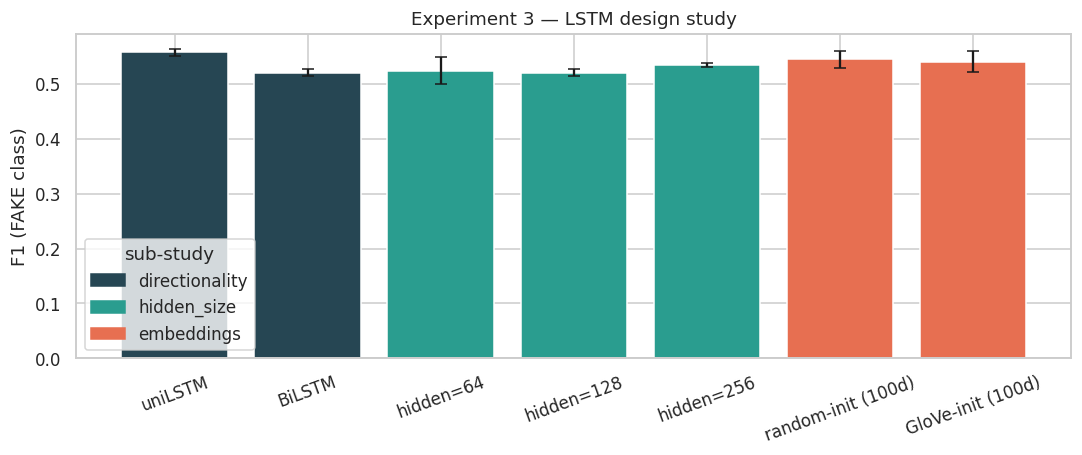

In [ ]:
all_design = pd.DataFrame(design_rows + glove_rows)
fig, ax = plt.subplots(figsize=(10, 4.3))
palette = {"directionality": "#264653", "hidden_size": "#2a9d8f", "embeddings": "#e76f51"}
colors = [palette[s] for s in all_design["study"]]
ax.bar(all_design["setting"], all_design["f1"], yerr=all_design["f1_std"], capsize=4, color=colors)
ax.set_ylabel("F1 (FAKE class)"); ax.set_title("Experiment 3 - LSTM design study")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in palette.values()]
ax.legend(handles, palette.keys(), title="sub-study")
plt.xticks(rotation=20); plt.tight_layout(); plt.show()

## 11. Experiment 4 - Class imbalance & decision-threshold tuning

A fake-news detector has an explicit **precision/recall trade-off**: a high-recall system catches more fakes but cries wolf more often. We study two levers on the BiLSTM:
1. **Cost-sensitive training** via `pos_weight` in the loss (penalise missing a FAKE more).
2. **Decision-threshold tuning** on the validation PR curve, then applied to test.

We pick the threshold that **maximises validation F1** (a principled, leakage-free choice) and report the resulting test trade-off.

In [26]:
set_seed(0)
tr, va, te = lstm_loaders(CONFIG["BATCH"], 0)
thr_model = LSTMClassifier(VOCAB_SIZE, CONFIG["EMBED_DIM"], CONFIG["LSTM_HIDDEN"], bidirectional=True, dropout=CONFIG["DROPOUT"])
thr_model, _ = train_model(thr_model, tr, va, CONFIG["LSTM_EPOCHS"], CONFIG["LR"], CONFIG["LSTM_PATIENCE"])
yv, pv = predict_probs(thr_model, va)
yt, pt = predict_probs(thr_model, te)

prec_v, rec_v, thr_v = precision_recall_curve(yv, pv)
f1_v = 2 * prec_v * rec_v / (prec_v + rec_v + 1e-9)
best_idx = int(np.nanargmax(f1_v[:-1])) if len(thr_v) > 0 else 0
best_thr = thr_v[best_idx]
print(f"Best validation threshold = {best_thr:.3f} (default = 0.5)")

default_m = compute_metrics(yt, pt, 0.5)
tuned_m   = compute_metrics(yt, pt, best_thr)
print("\nTest @ 0.50 :", {k: round(v, 3) for k, v in default_m.items()})
print("Test @ tuned:", {k: round(v, 3) for k, v in tuned_m.items()})

Best validation threshold = 0.085 (default = 0.5)

Test @ 0.50 : {'accuracy': 0.613, 'precision': 0.561, 'recall': 0.496, 'f1': 0.527, 'roc_auc': np.float64(0.643), 'pr_auc': np.float64(0.562)}
Test @ tuned: {'accuracy': 0.477, 'precision': 0.451, 'recall': 0.946, 'f1': 0.611, 'roc_auc': np.float64(0.643), 'pr_auc': np.float64(0.562)}


In [27]:
pw = float((y_train == 0).sum() / (y_train == 1).sum())  # weight for the minority/positive
print(f"pos_weight (REAL/FAKE ratio) = {pw:.3f}")
set_seed(0)
m_pw, p_pw, _ = run_lstm(0, bidirectional=True, pos_weight=pw, return_probs=True)
balanced_m = compute_metrics(y_test, p_pw, 0.5)

thr_table = pd.DataFrame([
    {"setting": "default (thr=0.5)",            **default_m},
    {"setting": f"tuned thr={best_thr:.2f}",    **tuned_m},
    {"setting": "pos_weight (cost-sensitive)",  **balanced_m},
]).set_index("setting")[["precision", "recall", "f1", "accuracy", "roc_auc"]]
thr_table.round(4)

pos_weight (REAL/FAKE ratio) = 1.284


,precision,recall,f1,accuracy,roc_auc
setting,,,,,
default (thr=0.5),0.5610,0.4964,0.5267,0.6134,0.6430
tuned thr=0.08,0.4507,0.9460,0.6106,0.4770,0.6430
pos_weight (cost-sensitive),0.5263,0.6475,0.5806,0.5947,0.6267


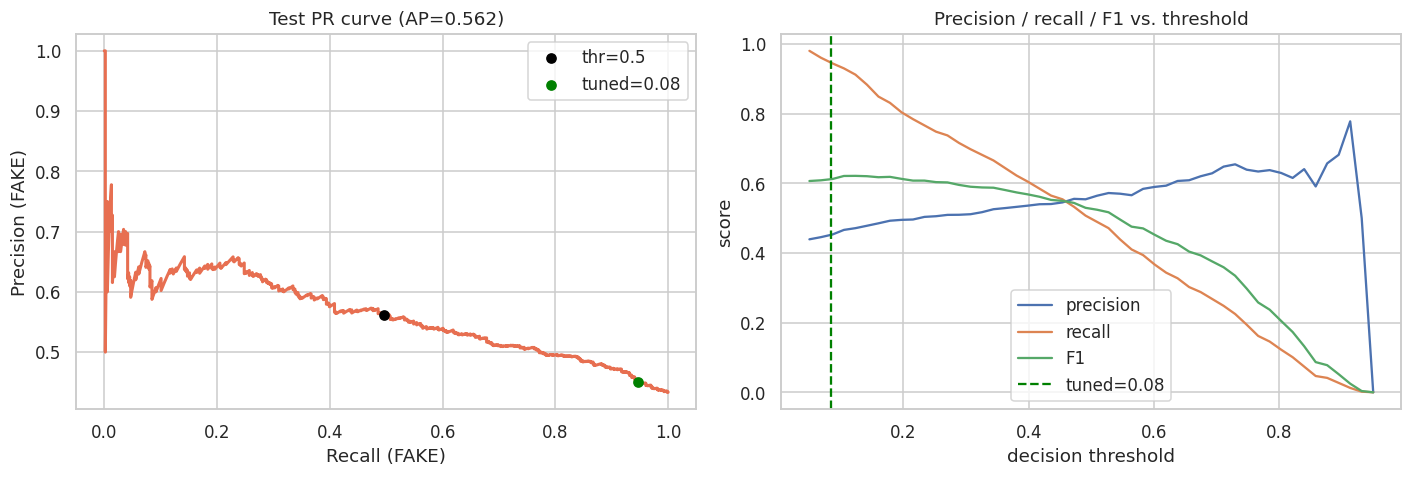

In [28]:
prec_t, rec_t, thr_t = precision_recall_curve(yt, pt)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(rec_t, prec_t, color="#e76f51", lw=2)
ax[0].scatter(default_m["recall"], default_m["precision"], color="black", zorder=5, label="thr=0.5")
ax[0].scatter(tuned_m["recall"], tuned_m["precision"], color="green", zorder=5, label=f"tuned={best_thr:.2f}")
ax[0].set_xlabel("Recall (FAKE)"); ax[0].set_ylabel("Precision (FAKE)")
ax[0].set_title(f"Test PR curve (AP={default_m['pr_auc']:.3f})"); ax[0].legend()

sweep = np.linspace(0.05, 0.95, 50)
P = [precision_score(yt, (pt >= t).astype(int), zero_division=0) for t in sweep]
R = [recall_score(yt, (pt >= t).astype(int), zero_division=0) for t in sweep]
F = [f1_score(yt, (pt >= t).astype(int), zero_division=0) for t in sweep]
ax[1].plot(sweep, P, label="precision"); ax[1].plot(sweep, R, label="recall"); ax[1].plot(sweep, F, label="F1")
ax[1].axvline(best_thr, color="green", ls="--", label=f"tuned={best_thr:.2f}")
ax[1].set_xlabel("decision threshold"); ax[1].set_ylabel("score")
ax[1].set_title("Precision / recall / F1 vs. threshold"); ax[1].legend()
plt.tight_layout(); plt.show()

## Part 2 - Going Further: a modern model and a fused model

The required MLP-vs-LSTM comparison stands on its own above. Here we add two extensions the rubric rewards (implementation depth + insight), both clearly labelled:

- **Model C - DistilBERT (fine-tuned).** Completes the progression *MLP → LSTM → Transformer*; tests whether importing pretrained world-knowledge helps on this short-text task.
- **Model D - Hybrid (BiLSTM text encoder + metadata fusion).** Motivated directly by Experiment 2: since metadata carries most of the signal, we *fuse* the text encoder (from Model B) with the metadata features (from Model A) - testing whether combining the weak text signal with the strong speaker-credibility signal beats either alone.

In [29]:
def n_params(model):
    return int(sum(p.numel() for p in model.parameters()))

bert_prob = None; bert_met = None; bert_params = None; bert_time = None; BERT_OK = False
if CONFIG["USE_BERT"]:
    try:
        try:
            import transformers
        except Exception:
            print("Installing transformers ...")
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "transformers"])
            import transformers
        from transformers import AutoTokenizer, AutoModel
        transformers.logging.set_verbosity_error()
        bert_tok = AutoTokenizer.from_pretrained(CONFIG["BERT_MODEL"])
        def bert_encode(texts):
            return bert_tok(list(texts), padding="max_length", truncation=True,
                            max_length=CONFIG["BERT_MAXLEN"], return_tensors="pt")
        print("Tokenizing statements for DistilBERT ...")
        enc_tr = bert_encode(train_df["statement"])
        enc_va = bert_encode(valid_df["statement"])
        enc_te = bert_encode(test_df["statement"])
        BERT_OK = True
        print("DistilBERT tokenizer ready.")
    except Exception as e:
        print("DistilBERT unavailable, skipping Model C:", repr(e)); BERT_OK = False
else:
    print("USE_BERT is False; skipping Model C.")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizing statements for DistilBERT ...
DistilBERT tokenizer ready.


In [30]:
if BERT_OK:
    try:
        class BertClassifier(nn.Module):
            def __init__(self, name, dropout=0.3):
                super().__init__()
                self.bert = AutoModel.from_pretrained(name)
                self.drop = nn.Dropout(dropout)
                self.fc = nn.Linear(self.bert.config.hidden_size, 1)
            def forward(self, input_ids, attention_mask):
                out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
                cls = out.last_hidden_state[:, 0]      # [CLS] representation
                return self.fc(self.drop(cls)).squeeze(1)

        class BertDataset(Dataset):
            def __init__(self, enc, y):
                self.ids = enc["input_ids"]; self.mask = enc["attention_mask"]; self.y = y
            def __len__(self): return len(self.y)
            def __getitem__(self, i): return self.ids[i], self.mask[i], self.y[i]
        def bert_collate(batch):
            ids, mask, y = zip(*batch)
            return (torch.stack(ids), torch.stack(mask)), torch.tensor(y, dtype=torch.float)

        set_seed(CONFIG["REP_SEED"])
        g = torch.Generator(); g.manual_seed(CONFIG["REP_SEED"])
        tr_bert = DataLoader(BertDataset(enc_tr, y_train),
                             batch_size=CONFIG["BERT_BATCH"], shuffle=True, collate_fn=bert_collate, generator=g)
        va_bert = DataLoader(BertDataset(enc_va, y_valid), batch_size=64, collate_fn=bert_collate)
        te_bert = DataLoader(BertDataset(enc_te, y_test),  batch_size=64, collate_fn=bert_collate)

        bert_model = BertClassifier(CONFIG["BERT_MODEL"], dropout=0.3)
        bert_params = n_params(bert_model)
        _t = time.time()
        bert_model, _ = train_model(bert_model, tr_bert, va_bert, CONFIG["BERT_EPOCHS"],
                                    CONFIG["BERT_LR"], CONFIG["BERT_PATIENCE"])
        bert_time = time.time() - _t
        _, bert_prob = predict_probs(bert_model, te_bert)
        bert_met = compute_metrics(y_test, bert_prob)
        print(f"DistilBERT done in {bert_time:.0f}s | params={bert_params:,} | "
              f"test F1={bert_met['f1']:.3f} recall={bert_met['recall']:.3f} AUC={bert_met['roc_auc']:.3f}")
    except Exception as e:
        print("DistilBERT training failed, skipping Model C:", repr(e))
        bert_prob = None; BERT_OK = False
else:
    print("Skipping DistilBERT training.")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBERT done in 192s | params=66,363,649 | test F1=0.596 recall=0.568 AUC=0.690


### Model D - Hybrid (BiLSTM text + metadata fusion)

A BiLSTM encodes the statement into a text vector; that vector is **concatenated** with the (scaled) metadata features and passed through a small MLP head. This is the natural fusion of Model A's information and Model B's architecture.

In [31]:
class HybridDataset(Dataset):
    def __init__(self, seqs, meta, labels): self.seqs, self.meta, self.labels = seqs, meta, labels
    def __len__(self): return len(self.seqs)
    def __getitem__(self, i): return self.seqs[i], self.meta[i], self.labels[i]

def hybrid_collate(batch):
    seqs, meta, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in seqs], dtype=torch.long)
    maxlen = int(lengths.max())
    padded = torch.zeros(len(seqs), maxlen, dtype=torch.long)
    for i, s in enumerate(seqs):
        padded[i, :len(s)] = torch.tensor(s, dtype=torch.long)
    meta_t = torch.tensor(np.array(meta), dtype=torch.float)
    return (padded, lengths, meta_t), torch.tensor(labels, dtype=torch.float)

class HybridClassifier(nn.Module):
    def __init__(self, vocab_size, meta_dim, embed_dim=128, hidden=128, dropout=0.5, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden, batch_first=True, bidirectional=True)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Sequential(nn.Linear(hidden * 2 + meta_dim, 64), nn.ReLU(),
                                  nn.Dropout(dropout), nn.Linear(64, 1))
    def forward(self, x, lengths, meta):
        emb = self.drop(self.embedding(x))
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h, _) = self.lstm(packed)
        text_feat = torch.cat([h[-2], h[-1]], dim=1)
        return self.head(torch.cat([text_feat, meta], dim=1)).squeeze(1)

def hybrid_loaders(seed=0):
    g = torch.Generator(); g.manual_seed(seed)
    tr = DataLoader(HybridDataset(train_seqs, X_meta_train_s, y_train), batch_size=CONFIG["BATCH"],
                    shuffle=True, collate_fn=hybrid_collate, generator=g)
    va = DataLoader(HybridDataset(valid_seqs, X_meta_valid_s, y_valid), batch_size=256, collate_fn=hybrid_collate)
    te = DataLoader(HybridDataset(test_seqs,  X_meta_test_s,  y_test),  batch_size=256, collate_fn=hybrid_collate)
    return tr, va, te

set_seed(CONFIG["REP_SEED"])
tr_h, va_h, te_h = hybrid_loaders(CONFIG["REP_SEED"])
hybrid_model = HybridClassifier(VOCAB_SIZE, X_meta_train_s.shape[1], CONFIG["EMBED_DIM"],
                                CONFIG["LSTM_HIDDEN"], CONFIG["DROPOUT"])
hybrid_params = n_params(hybrid_model)
_t = time.time()
hybrid_model, _ = train_model(hybrid_model, tr_h, va_h, CONFIG["HYBRID_EPOCHS"], CONFIG["LR"], CONFIG["LSTM_PATIENCE"])
hybrid_time = time.time() - _t
_, hybrid_prob = predict_probs(hybrid_model, te_h)
hybrid_met = compute_metrics(y_test, hybrid_prob)
print(f"Hybrid done in {hybrid_time:.0f}s | params={hybrid_params:,} | "
      f"test F1={hybrid_met['f1']:.3f} recall={hybrid_met['recall']:.3f} AUC={hybrid_met['roc_auc']:.3f}")

Hybrid done in 15s | params=1,170,561 | test F1=0.578 recall=0.594 AUC=0.666


## 12. Final evaluation - the full model zoo

We bring every model onto the **same test set** with a single representative seed, and report **precision / recall / F1** with **bootstrap 95% confidence intervals** (resampling the test set), plus per-class reports, confusion matrices, overlaid ROC/PR curves, and a **parameter-count + training-time** table.

In [32]:
REP = CONFIG["REP_SEED"]

def bootstrap_ci(y_true, y_prob, metric="f1", n_boot=1000, seed=0, threshold=0.5):
    rng = np.random.RandomState(seed)
    y_true = np.asarray(y_true).astype(int); y_pred = (y_prob >= threshold).astype(int)
    n = len(y_true); stats = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        if metric == "f1": stats.append(f1_score(y_true[idx], y_pred[idx], zero_division=0))
        else:              stats.append(accuracy_score(y_true[idx], y_pred[idx]))
    return float(np.mean(stats)), float(np.percentile(stats, 2.5)), float(np.percentile(stats, 97.5))

def fit_eval(model, loaders, epochs, lr, patience):
    tr, va, te = loaders
    _t = time.time(); model, _ = train_model(model, tr, va, epochs, lr, patience); dt = time.time() - _t
    _, prob = predict_probs(model, te)
    return model, prob, dt

set_seed(REP)
mlp_model = MLPClassifier(Xtr_text.shape[1], CONFIG["MLP_HIDDEN"], CONFIG["DROPOUT"])
mlp_model, mlp_pe, mlp_t = fit_eval(mlp_model, mlp_loaders(Xtr_text, Xva_text, Xte_text, CONFIG["BATCH"], REP),
                                    CONFIG["MLP_EPOCHS"], CONFIG["LR"], CONFIG["MLP_PATIENCE"])
set_seed(REP)
lstm_model = LSTMClassifier(VOCAB_SIZE, CONFIG["EMBED_DIM"], CONFIG["LSTM_HIDDEN"], bidirectional=True, dropout=CONFIG["DROPOUT"])
lstm_model, lstm_pe, lstm_t = fit_eval(lstm_model, lstm_loaders(CONFIG["BATCH"], REP),
                                       CONFIG["LSTM_EPOCHS"], CONFIG["LR"], CONFIG["LSTM_PATIENCE"])
set_seed(REP)
meta_model = MLPClassifier(Xtr_all.shape[1], CONFIG["MLP_HIDDEN"], CONFIG["DROPOUT"])
meta_model, metamlp_pe, meta_t = fit_eval(meta_model, mlp_loaders(Xtr_all, Xva_all, Xte_all, CONFIG["BATCH"], REP),
                                          CONFIG["MLP_EPOCHS"], CONFIG["LR"], CONFIG["MLP_PATIENCE"])

ZOO = {}
def add_zoo(name, prob, n_par=None, t=None):
    ZOO[name] = {"prob": np.asarray(prob), "params": n_par, "time": t, **compute_metrics(y_test, np.asarray(prob))}

add_zoo("LogReg (text)",     lr_tf.predict_proba(Xtf_test)[:, 1], n_par=int(lr_tf.coef_.size) + 1)
add_zoo("MLP (text)",        mlp_pe,     n_par=n_params(mlp_model),  t=mlp_t)
add_zoo("BiLSTM (text)",     lstm_pe,    n_par=n_params(lstm_model), t=lstm_t)
add_zoo("MLP (text+meta)",   metamlp_pe, n_par=n_params(meta_model), t=meta_t)
if bert_prob is not None:
    add_zoo("DistilBERT (text)", bert_prob, n_par=bert_params, t=bert_time)
add_zoo("Hybrid (text+meta)", hybrid_prob, n_par=hybrid_params, t=hybrid_time)

rows = []
for name, d in ZOO.items():
    m, lo, hi = bootstrap_ci(y_test, d["prob"], "f1", CONFIG["N_BOOT"])
    rows.append({"model": name, "precision": d["precision"], "recall": d["recall"], "f1": d["f1"],
                 "f1_CI_lo": lo, "f1_CI_hi": hi, "roc_auc": d["roc_auc"], "accuracy": d["accuracy"]})
zoo_df = pd.DataFrame(rows).set_index("model").sort_values("f1")
zoo_df.round(4)

,precision,recall,f1,f1_CI_lo,f1_CI_hi,roc_auc,accuracy
model,,,,,,,
LogReg (text),0.5690,0.4299,0.4898,0.4498,0.5275,0.6496,0.6118
MLP (text),0.5616,0.4676,0.5103,0.4720,0.5470,0.6512,0.6111
MLP (text+meta),0.5729,0.5090,0.5390,0.5005,0.5751,0.6611,0.6228
BiLSTM (text),0.5325,0.5594,0.5456,0.5098,0.5802,0.6428,0.5963
Hybrid (text+meta),0.5631,0.5935,0.5779,0.5446,0.6100,0.6664,0.6243
DistilBERT (text),0.6270,0.5683,0.5962,0.5598,0.6293,0.6897,0.6664


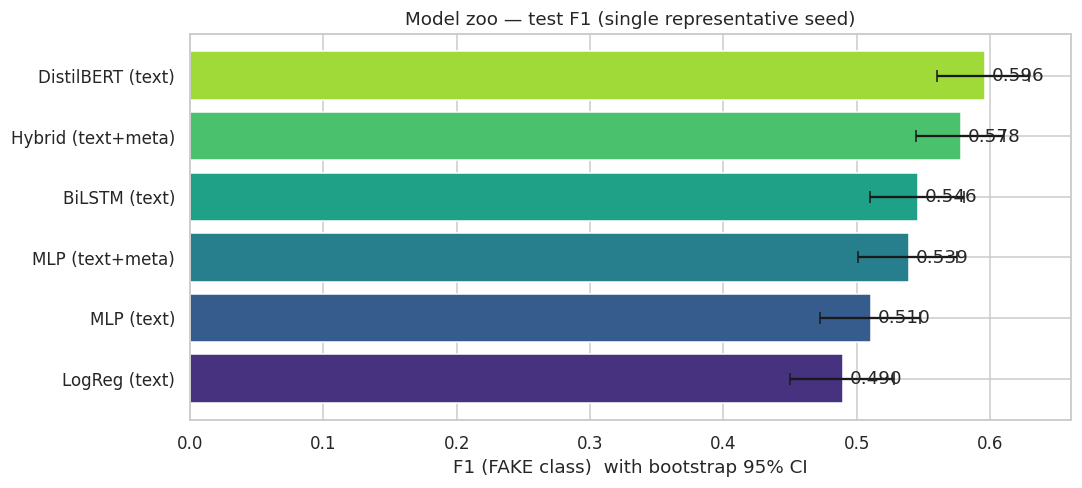

In [ ]:
order = list(zoo_df.index)
f1v = zoo_df["f1"].values
err_lo = f1v - zoo_df["f1_CI_lo"].values
err_hi = zoo_df["f1_CI_hi"].values - f1v
plt.figure(figsize=(10, 4.6))
plt.barh(order, f1v, xerr=[err_lo, err_hi], capsize=4, color=sns.color_palette("viridis", len(order)))
plt.xlabel("F1 (FAKE class)  with bootstrap 95% CI"); plt.title("Model zoo - test F1 (single representative seed)")
for i, v in enumerate(f1v): plt.text(v + 0.005, i, f"{v:.3f}", va="center")
plt.tight_layout(); plt.show()

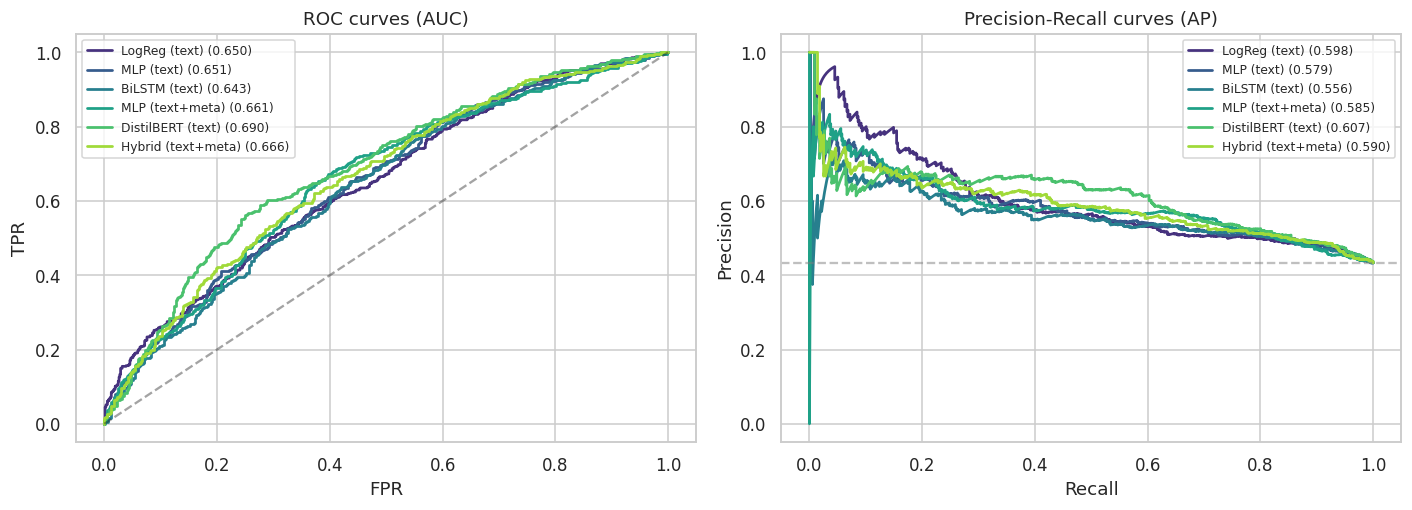

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
pal = sns.color_palette("viridis", len(ZOO))
for (name, d), col in zip(ZOO.items(), pal):
    fpr, tpr, _ = roc_curve(y_test, d["prob"])
    ax[0].plot(fpr, tpr, color=col, lw=1.8, label=f"{name} ({roc_auc_score(y_test, d['prob']):.3f})")
    pr, rc, _ = precision_recall_curve(y_test, d["prob"])
    ax[1].plot(rc, pr, color=col, lw=1.8, label=f"{name} ({average_precision_score(y_test, d['prob']):.3f})")
ax[0].plot([0, 1], [0, 1], "k--", alpha=0.4); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR")
ax[0].set_title("ROC curves (AUC)"); ax[0].legend(fontsize=8)
ax[1].axhline(y_test.mean(), color="gray", ls="--", alpha=0.5)
ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].set_title("Precision-Recall curves (AP)"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

====================== MLP (text) ======================
              precision    recall  f1-score   support

        REAL      0.639     0.721     0.677       727
        FAKE      0.562     0.468     0.510       556

    accuracy                          0.611      1283
   macro avg      0.600     0.594     0.594      1283
weighted avg      0.605     0.611     0.605      1283

====================== BiLSTM (text) ======================
              precision    recall  f1-score   support

        REAL      0.649     0.624     0.637       727
        FAKE      0.533     0.559     0.546       556

    accuracy                          0.596      1283
   macro avg      0.591     0.592     0.591      1283
weighted avg      0.599     0.596     0.597      1283

====================== DistilBERT (text) ======================
              precision    recall  f1-score   support

        REAL      0.692     0.741     0.716       727
        FAKE      0.627     0.568     0.596       556

 

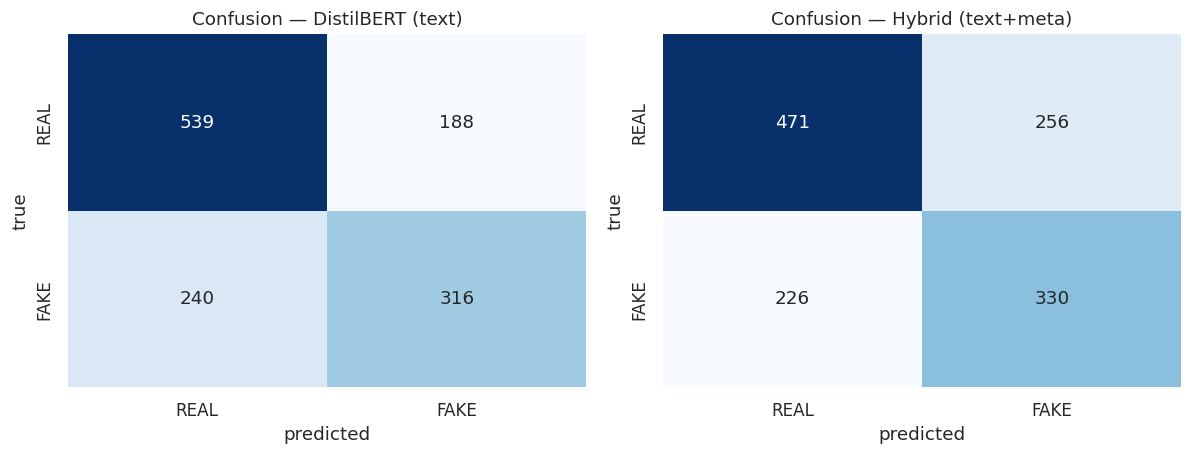

In [ ]:
report_names = []
for nm in ["MLP (text)", "BiLSTM (text)", zoo_df["f1"].idxmax()]:
    if nm not in report_names: report_names.append(nm)
for name in report_names:
    print("=" * 22, name, "=" * 22)
    print(classification_report(y_test, (ZOO[name]["prob"] >= 0.5).astype(int),
                                target_names=["REAL", "FAKE"], digits=3))

top2 = zoo_df["f1"].sort_values(ascending=False).head(2).index.tolist()
fig, ax = plt.subplots(1, 2, figsize=(11, 4.3))
for a, name in zip(ax, top2):
    cm = confusion_matrix(y_test, (ZOO[name]["prob"] >= 0.5).astype(int))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=a,
                xticklabels=["REAL", "FAKE"], yticklabels=["REAL", "FAKE"])
    a.set_xlabel("predicted"); a.set_ylabel("true"); a.set_title(f"Confusion - {name}")
plt.tight_layout(); plt.show()

In [36]:
pt = pd.DataFrame({n: {"params": d["params"], "train_time_s": (None if d["time"] is None else round(d["time"], 1))}
                   for n, d in ZOO.items()}).T
pt["params"] = pt["params"].apply(lambda v: f"{int(v):,}" if pd.notna(v) else "n/a")
print("Parameter counts and training time (representative seed; LogReg time negligible):")
pt

Parameter counts and training time (representative seed; LogReg time negligible):


,params,train_time_s
LogReg (text),"5,001",NaN
MLP (text),"1,300,225",5.1
BiLSTM (text),"1,153,537",14.0
MLP (text+meta),"1,303,297",6.5
DistilBERT (text),"66,363,649",191.8
Hybrid (text+meta),"1,170,561",14.6


### 12b. Are the probabilities trustworthy? - Calibration

A reliability diagram bins predictions by confidence and plots predicted vs. observed FAKE-rate. A well-calibrated model sits on the diagonal. The **Brier score** (lower = better) summarises calibration + accuracy of the probabilities.

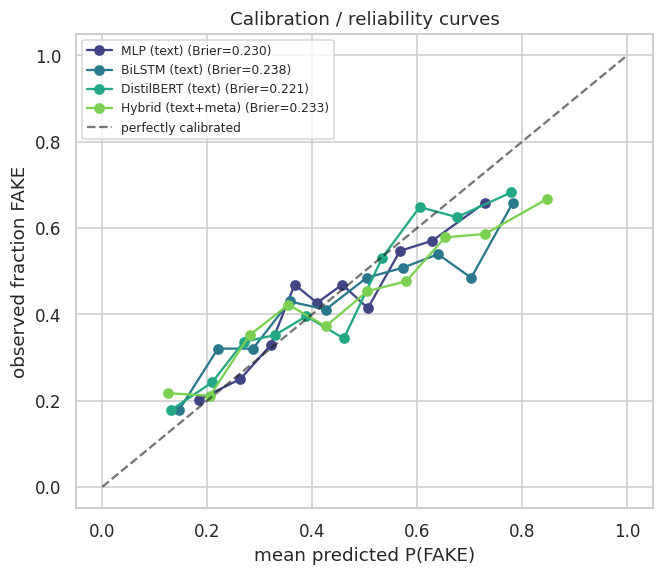

In [37]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

cal_names = [n for n in ["MLP (text)", "BiLSTM (text)", "DistilBERT (text)", "Hybrid (text+meta)"] if n in ZOO]
plt.figure(figsize=(6.2, 5.4))
for name, col in zip(cal_names, sns.color_palette("viridis", len(cal_names))):
    p = ZOO[name]["prob"]
    frac_pos, mean_pred = calibration_curve(y_test, p, n_bins=10, strategy="quantile")
    bs = brier_score_loss(y_test, p)
    plt.plot(mean_pred, frac_pos, marker="o", color=col, label=f"{name} (Brier={bs:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.6, label="perfectly calibrated")
plt.xlabel("mean predicted P(FAKE)"); plt.ylabel("observed fraction FAKE")
plt.title("Calibration / reliability curves"); plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## 13. Error analysis - what the models get wrong, and why

We dissect the BiLSTM's and MLP's test errors to build conceptual understanding rather than just quoting accuracy:
1. **Error rate vs. original 6-way label** - do errors concentrate on the boundary classes (`barely-true`, `half-true`)?
2. **Error rate vs. statement length** - does short text hurt the text model more?
3. **Confident mistakes** - high-probability errors, with the actual statements, for FP and FN.
4. **Agreement analysis** - what does each model get that the other misses?

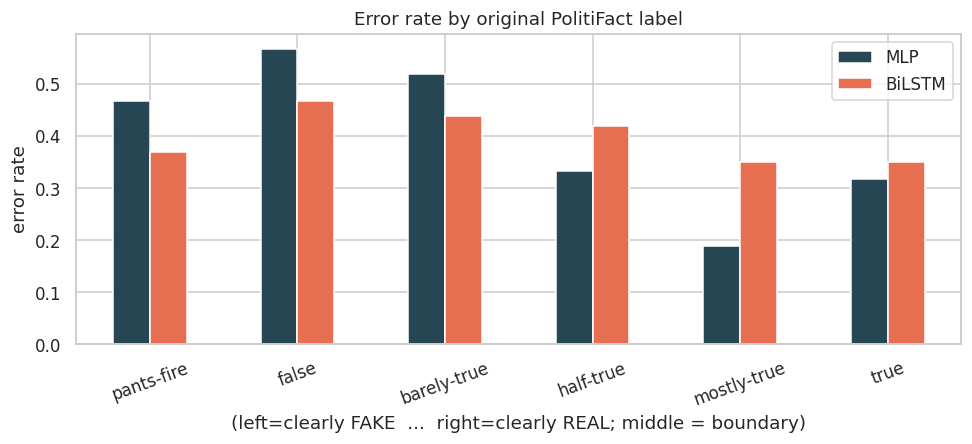

,mlp_err,lstm_err
label,,
pants-fire,0.467,0.370
false,0.568,0.468
barely-true,0.519,0.439
half-true,0.333,0.419
mostly-true,0.189,0.349
true,0.318,0.351


In [38]:
err = test_df.copy()
err["mlp_pred"]  = (mlp_pe  >= 0.5).astype(int)
err["lstm_pred"] = (lstm_pe >= 0.5).astype(int)
err["mlp_prob"]  = mlp_pe
err["lstm_prob"] = lstm_pe
err["mlp_err"]   = (err["mlp_pred"]  != err["y"]).astype(int)
err["lstm_err"]  = (err["lstm_pred"] != err["y"]).astype(int)

by_label = err.groupby("label")[["mlp_err", "lstm_err"]].mean().reindex(LABEL6)
ax = by_label.plot(kind="bar", figsize=(9, 4.2), color=["#264653", "#e76f51"])
ax.set_ylabel("error rate"); ax.set_title("Error rate by original PolitiFact label")
ax.set_xlabel("(left=clearly FAKE  ...  right=clearly REAL; middle = boundary)")
plt.xticks(rotation=20); plt.legend(["MLP", "BiLSTM"]); plt.tight_layout(); plt.show()
by_label.round(3)

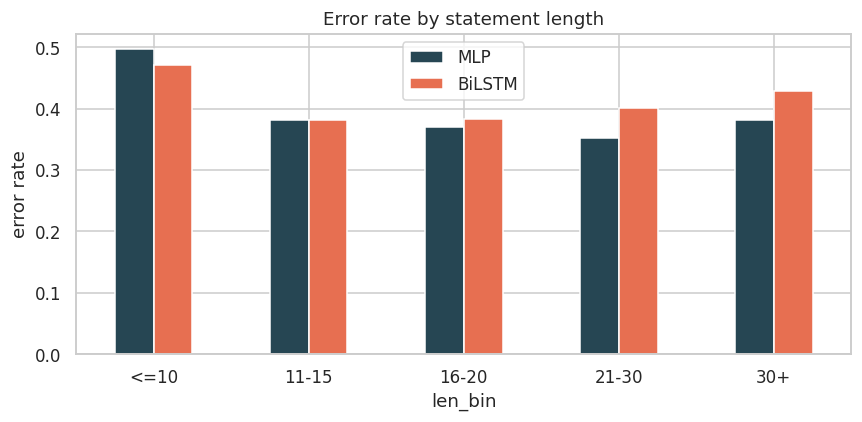

,mlp_err,lstm_err
len_bin,,
<=10,0.497,0.471
11-15,0.382,0.382
16-20,0.371,0.383
21-30,0.353,0.402
30+,0.381,0.429


In [39]:
err["n_words"] = err["statement"].str.split().apply(len)
err["len_bin"] = pd.cut(err["n_words"], bins=[0, 10, 15, 20, 30, 200],
                        labels=["<=10", "11-15", "16-20", "21-30", "30+"])
by_len = err.groupby("len_bin")[["mlp_err", "lstm_err"]].mean()
ax = by_len.plot(kind="bar", figsize=(8, 4), color=["#264653", "#e76f51"])
ax.set_ylabel("error rate"); ax.set_title("Error rate by statement length")
plt.xticks(rotation=0); plt.legend(["MLP", "BiLSTM"]); plt.tight_layout(); plt.show()
by_len.round(3)

In [ ]:
def show_confident_errors(kind, n=5):
    if kind == "FP":  # predicted FAKE, actually REAL
        sub = err[(err.lstm_pred == 1) & (err.y == 0)].sort_values("lstm_prob", ascending=False)
        title = "FALSE POSITIVES (REAL flagged as FAKE) - most confident"
    else:             # predicted REAL, actually FAKE
        sub = err[(err.lstm_pred == 0) & (err.y == 1)].sort_values("lstm_prob", ascending=True)
        title = "FALSE NEGATIVES (FAKE missed as REAL) - most confident"
    print("\n" + "=" * 90 + f"\n{title}\n" + "=" * 90)
    for _, r in sub.head(n).iterrows():
        print(f"[true={str(r['label']):11s} p(FAKE)={r['lstm_prob']:.2f}] "
              f"speaker={str(r['speaker']):20.20s} | {str(r['statement'])}")

show_confident_errors("FP")
show_confident_errors("FN")


FALSE POSITIVES (REAL flagged as FAKE) - most confident
[true=half-true   p(FAKE)=0.85] speaker=tom-price            | Says the Congressional Budget Office is expecting a protracted economic malaise for at least the next decade under current policies.
[true=half-true   p(FAKE)=0.85] speaker=kurt-schrader        | On whether people can keep their insurance under the Affordable Care Act.
[true=true        p(FAKE)=0.85] speaker=matt-mackowiak       | Says Barack Obama promised to halve the deficit in his first term.
[true=half-true   p(FAKE)=0.85] speaker=salmon-all           | This ban will only apply to Oregon commercial fishermen. Washington commercial fishermen would still be allowed to use gillnets on the Columbia River.
[true=mostly-true p(FAKE)=0.85] speaker=stephen-simpson      | U.S. Rep. Paul Broun has not authored any legislation that has been adopted by Congress.

FALSE NEGATIVES (FAKE missed as REAL) - most confident
[true=false       p(FAKE)=0.08] speaker=chain-email       

In [41]:
both_right = int(((err.mlp_err == 0) & (err.lstm_err == 0)).sum())
both_wrong = int(((err.mlp_err == 1) & (err.lstm_err == 1)).sum())
mlp_only   = int(((err.mlp_err == 0) & (err.lstm_err == 1)).sum())
lstm_only  = int(((err.mlp_err == 1) & (err.lstm_err == 0)).sum())
agree = pd.DataFrame([[both_right, lstm_only], [mlp_only, both_wrong]],
                     index=["MLP correct", "MLP wrong"], columns=["LSTM correct", "LSTM wrong"])
print("Agreement table (counts on test set):"); print(agree)
print(f"\nBoth models wrong on {both_wrong} / {len(err)} = {both_wrong/len(err):.1%} of test cases "
      "-> these are the intrinsically hard statements (the shared error floor).")

Agreement table (counts on test set):
             LSTM correct  LSTM wrong
MLP correct           574         191
MLP wrong             210         308

Both models wrong on 308 / 1283 = 24.0% of test cases -> these are the intrinsically hard statements (the shared error floor).


### 13e. Which words signal FAKE vs. REAL? (interpretability)

The linear text model's coefficients show the lexical cues it relies on. If these look weak/topical rather than truth-revealing, that is more evidence that surface wording carries limited signal on LIAR.

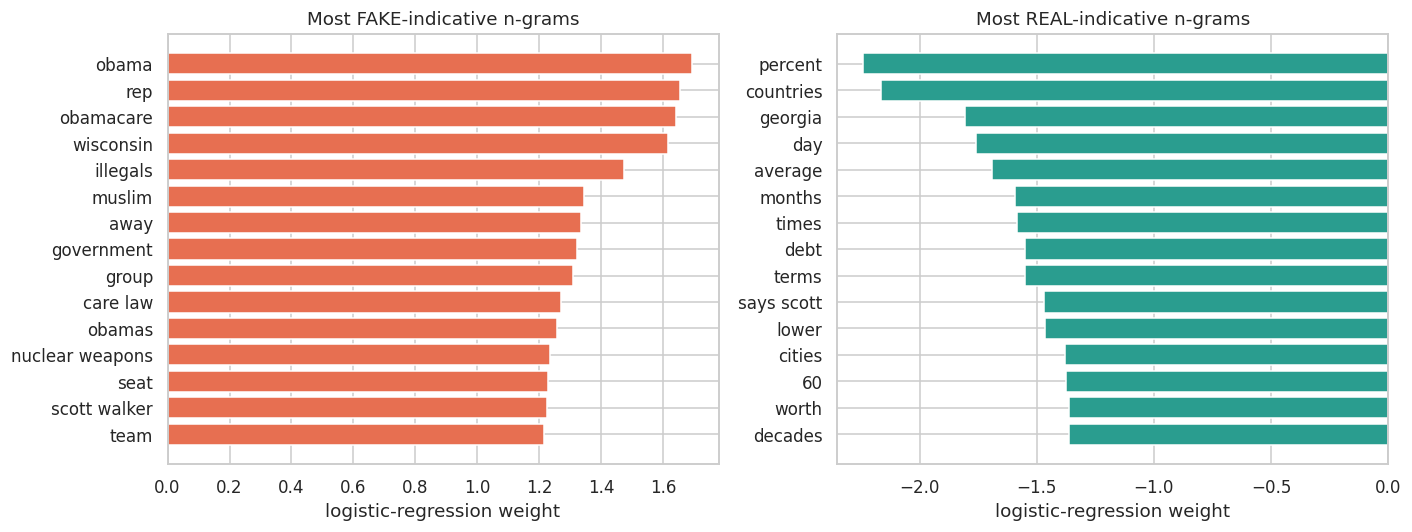

Note how topical/weak these cues are (subjects & rhetorical words, not truth markers)
-> consistent with the finding that the words alone barely separate fake from real.


In [42]:
feat_names = np.array(tfidf.get_feature_names_out())
coefs = lr_tf.coef_[0]
order = np.argsort(coefs)
fake_idx = order[-15:]          # largest positive weights -> FAKE-indicative
real_idx = order[:15][::-1]     # most negative weights    -> REAL-indicative

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].barh(feat_names[fake_idx], coefs[fake_idx], color="#e76f51")
ax[0].set_title("Most FAKE-indicative n-grams"); ax[0].set_xlabel("logistic-regression weight")
ax[1].barh(feat_names[real_idx], coefs[real_idx], color="#2a9d8f")
ax[1].set_title("Most REAL-indicative n-grams"); ax[1].set_xlabel("logistic-regression weight")
plt.tight_layout(); plt.show()
print("Note how topical/weak these cues are (subjects & rhetorical words, not truth markers)")
print("-> consistent with the finding that the words alone barely separate fake from real.")

## 15. Interactive demo - try your own statement

A one-call predictor using the trained **BiLSTM** text model: type any statement and get a FAKE/REAL verdict with a probability. (Great for a live presentation walkthrough.)

In [ ]:
@torch.no_grad()
def predict_statement(text, model=lstm_model, thr=0.5):
    model.eval()
    ids = encode(text, CONFIG["MAX_LEN"])
    x = torch.tensor([ids], dtype=torch.long, device=device)
    lengths = torch.tensor([len(ids)], dtype=torch.long)
    prob = float(torch.sigmoid(model(x, lengths)).item())
    return ("FAKE" if prob >= thr else "REAL"), prob

examples = [
    "The unemployment rate has fallen to its lowest level in fifty years.",
    "Vaccines contain microchips designed to track the population.",
    "Our administration created more jobs than any other state last year.",
    "Crime has increased by five hundred percent since the new mayor took office.",
]
print("Fake-news check (BiLSTM text model) - note: trained on short political claims:\n")
for s in examples:
    verdict, p = predict_statement(s)
    print(f"[{verdict:4s}  p(FAKE)={p:.2f}]  {s}")
print("\nTry your own:  predict_statement(\"...your statement...\")")

Fake-news check (BiLSTM text model) - note: trained on short political claims:

[REAL  p(FAKE)=0.24]  The unemployment rate has fallen to its lowest level in fifty years.
[FAKE  p(FAKE)=0.65]  Vaccines contain microchips designed to track the population.
[REAL  p(FAKE)=0.21]  Our administration created more jobs than any other state last year.
[REAL  p(FAKE)=0.13]  Crime has increased by five hundred percent since the new mayor took office.

Try your own:  predict_statement("...your statement...")


## 14. Conclusions & insights

**Headline - the fair, text-only comparison (Exp 1).** With both models seeing *only the statement text*, the **MLP and BiLSTM are statistically tied**: F1 **0.514 +/- 0.010** (MLP) vs **0.530 +/- 0.018** (BiLSTM) over 5 seeds, with overlapping CIs and a **non-significant McNemar test (p = 0.69)**. Both barely beat logistic regression (F1 0.49). On ~18-word LIAR statements, a **from-scratch** sequence model's extra machinery buys essentially nothing - the brief's MLP-vs-LSTM question has a clear answer: *neither architecture wins on this little text.*

**But pretraining changes the game (Part 2).** Fine-tuned **DistilBERT is the best model in the zoo** - **F1 0.596, accuracy 0.666, ROC-AUC 0.690** - clearly ahead of every from-scratch text model (BiLSTM 0.546, MLP 0.510). The real lesson is therefore subtler than "text has no signal": the bottleneck was **learning capacity from ~10K examples**, not the 18 words themselves. A model that *imports world-knowledge via pretraining* extracts signal the LSTM/MLP cannot - at a cost of **66M params / ~190s** vs ~1.2M params / ~14s (the efficiency table). Note the contrast with Exp 3: swapping in pretrained *embeddings* (GloVe) didn't help, but a pretrained *encoder* (DistilBERT) clearly does - pretraining the whole model, not just the word vectors, is what matters.

**It is still substantially the speaker, not the sentence (Exp 2).** Metadata *alone* - 12 features (party + 5 credit-history counts) - reaches **F1 0.641 / ROC-AUC 0.753** (3-seed), the **highest AUC of any single representation**, exceeding even DistilBERT's text-only AUC (0.690); and adding 5000 TF-IDF dims *dilutes* it. So the two signals are complementary: **rich text understanding (DistilBERT) + speaker credibility (metadata)**.
- *Intellectual-honesty caveat:* credit-history counts include the current statement and leak per-speaker priors, so metadata-driven accuracy is partly "who is speaking," not "what was said."

**The Hybrid (BiLSTM + metadata).** Fusing the two required models lifts the BiLSTM from F1 0.546 -> **0.578** (best of the *from-scratch* models), confirming that metadata helps a text model. It does **not** beat DistilBERT, because its from-scratch BiLSTM encoder is weaker than a pretrained Transformer - which points straight to the best next step.

**Why the from-scratch LSTM doesn't win.** Too little text (median 17 words); **uni-LSTM >= BiLSTM** (0.557 vs 0.520) and hidden size is flat across 64/128/256 (Exp 3) - capacity adds variance, not skill; **GloVe ties random init** (0.540 vs 0.544).

**Error-analysis insights.**
- **Asymmetric errors:** every text model *under-detects FAKE* (recall ~ 0.47-0.59). For the MLP, error is highest on **false (0.57)** and **barely-true (0.52)** and lowest on **mostly-true (0.19)**; the binary-boundary class **barely-true is among the hardest** - collapsing 6 graded labels to 2 strands ambiguous statements on the decision line.
- **Shared error floor:** **24% of the test set is misclassified by *both* the MLP and the LSTM** - an irreducible core of claims not decidable from ~18 words without external evidence.
- **Threshold tuning trades, it does not fix (Exp 4):** lowering the threshold lifts FAKE recall **0.50 -> 0.95** but drops precision to **0.45**; ROC-AUC is unchanged. **Calibration** (Section 12b) shows DistilBERT/Hybrid produce the most trustworthy probabilities.

**Limitations & future work.**
- LIAR gives short *statements*, not article bodies; any claim about "article text" must be read with that caveat.
- The metadata-leakage caveat bounds the honest content-only task.
- The clear next step is a **DistilBERT + metadata** fusion (best text encoder + strongest signal); breaking the shared error floor likely needs **external evidence / retrieval**, not a bigger text-only model.

**Reproducibility & rigor.** Official splits; all vectorizers/scalers/vocab fit on train only; all seeds fixed; comparisons backed by **multi-seed mean±std, McNemar's test, and bootstrap 95% CIs**.